## Событийная аналитика

Для расчёта любой метрики нужны данные, из которых она собирается. При этом и логика сбора, и логика обработки данных — результат конкретных решений, и каждое из этих решений напрямую влияет на итоговое значение метрики, а значит — и на решения, которые бизнес принимает на её основе.

**Качество любой метрики сверху ограничено качеством событий снизу.** 

На этом семинаре разберем особенности событийной аналитики.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 14,
    'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False,
})

def legend_below(ax, ncol=3):
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=ncol, frameon=False)

rng = np.random.default_rng(42)

In [3]:
def generate_events(n_users=12000, start='2026-08-03', weeks=5, seed=42):
    
    rng = np.random.default_rng(seed)
    start_ts = pd.Timestamp(start)
    horizon = weeks * 7 * 24 * 3600
    release_ts = pd.Timestamp('2026-08-24')

    platforms = rng.choice(['android', 'ios', 'web'], size=n_users, p=[.45, .30, .25])
    categories = np.array(['electronics', 'apparel', 'home', 'beauty', 'sport', 'grocery'])
    cat_price = {'electronics': 180, 'apparel': 45, 'home': 60, 'beauty': 25, 'sport': 70, 'grocery': 12}

    rows = []
    
    for u in range(n_users):
        
        uid, plat = f'u_{u:05d}', platforms[u]
        
        for s in range(rng.poisson(6) + 1):
            
            sess_start = start_ts + pd.Timedelta(seconds=float(rng.uniform(0, horizon)))
            cat = rng.choice(categories)
            t = sess_start
            n_views = 1 + rng.poisson(2)
            ev_in_session = ['view'] * n_views
            
            if rng.random() < 0.35:
                ev_in_session.append('cart')
                
                if rng.random() < 0.45:
                    ev_in_session.append('purchase')
            
            for i, etype in enumerate(ev_in_session):

                gap = rng.exponential(120) if rng.random() < 0.85 else rng.uniform(8*60, 40*60)
                t = t + pd.Timedelta(seconds=float(gap))
                eid = f'{uid}_s{s}_{i}'
                price = round(float(rng.lognormal(np.log(cat_price[cat]), 0.4)), 2)
                rows.append((eid, etype, t, uid, plat, cat, f'p_{rng.integers(0, 3000):04d}', price))

                if etype == 'view' and plat == 'android' and t >= release_ts and rng.random() < 0.5:
                    rows.append((eid, etype, t + pd.Timedelta(seconds=float(rng.uniform(0, 2))),
                                 uid, plat, cat, f'p_{rng.integers(0, 3000):04d}', price))
   
    df = pd.DataFrame(rows, columns=['event_id', 'event_type', 'ts', 'user_id',
                                     'platform', 'category', 'product_id', 'price'])
    
    return df.sort_values(['user_id', 'ts']).reset_index(drop=True)

In [4]:
events = generate_events()
events.head()

,event_id,event_type,ts,user_id,platform,category,product_id,price
0,u_00000_s1_0,view,2026-08-09 19:33:51.265817312,u_00000,web,home,p_1876,37.18
1,u_00000_s1_1,view,2026-08-09 19:34:01.258479628,u_00000,web,home,p_1657,88.45
2,u_00000_s1_2,cart,2026-08-09 19:34:33.363994283,u_00000,web,home,p_2768,46.14
3,u_00000_s4_0,view,2026-08-11 07:58:42.449213131,u_00000,web,beauty,p_0412,16.85
4,u_00000_s4_1,view,2026-08-11 07:58:52.251511165,u_00000,web,beauty,p_2596,20.69


### Модель события

#### От метрики к событию, не наоборот

Неправильный способ звучит разумно: «запишем все, потом разберемся». **Избыток событий прячет ответы так же надежно, как их отсутствие**.

Правильный способ — сначала решить, что именно вы хотите посчитать. Обсуждение рекомендуется начинать на уровне продакт-менеджер + аналитик, это поможет выстроить цепочку: поставленные задачи -> способы измерения -> метрики -> необходимые события. 

Пример: *«какие события нужны, чтобы посчитать активацию?»*

#### Схема

Событие — это единица поведенческих данных. Оно должно отвечать на **3 обязательных вопроса**:
1) Что произошло?  — название события
2) Когда произошло? — timestamp
3) С кем произошло? — идентификатор пользователя

+включать набор атрибутов, необходимых для построения метрик.

```json
{
  "event_name": "order_completed",
  "timestamp": "2026-09-11T14:32:07+05:00",
  "user_id": "u_00423",
  "params": {
    "order_value": 4990,
    "items_count": 3,
    "payment_method": "card"
  }
}
```

#### 1. Нейминг

**Object-action framework**

Объект + действие в прошедшем времени, единый регистр. Конкретная конвенция вторична — **консистентность первична**.


| Неверно | Верно|
|---|---|
| `click_buy_btn_2` | `order_completed` |
| `Purchase` / `purchase_success`| одно событие + свойство `source` |
| `srch` | `search_performed` |

#### 2. Время

Причины расхождений:

1) Клиентские часы врут
2) События опаздывают
3) Разные часовые пояса

Как именно считаем дату события — уже решение.

#### 3. Кто такой «пользователь»?

В данных мы засчитываем за пользователя его идентификатор, и эти идентификаторы могут быть разными.

| Идентификатор | Уровень надежности | Недостатки |
|---|---|---|
| **cookie** | низкий | очистки, инкогнито, ограниченный срок жизни |
| **device_id** | средний | ломается в обе стороны: семейный планшет = несколько людей под одним id; телефон + ноутбук = один человек под двумя |
| **user_id** | высокий | есть только у залогиненных, не защищен от мультиаккаунтов |


#### 4. Свойства события vs свойства пользователя

| | Свойство события | Свойство пользователя |
|---|---|---|
| Истинно | в момент события, навсегда | сейчас; перезаписывается |
| Примеры | цена, тариф на момент покупки, версия экрана | текущий город, текущий тариф |

**Правило исторической точности:** всё, что должно остаться правдой навсегда, пишется в событие в момент наступления.   

Amplitude — [Data Taxonomy Playbook](https://amplitude.com/docs/data/data-planning-playbook)

#### 🔎 Пример: атрибуция выручки
Пользователь дважды купил услугу на базовом тарифе, а потом еще раз на премиуме.

In [5]:
purchases = pd.DataFrame({
    'ts': pd.to_datetime(['2026-06-10', '2026-07-05', '2026-08-20']),
    'user_id': ['u_1'] * 3,
    'revenue': [100, 100, 300],
    'plan_at_purchase': ['basic', 'basic', 'premium'], # свойство события
})

current_user_plan = {'u_1': 'premium'} # свойство пользователя

In [6]:
correct = purchases.groupby('plan_at_purchase')['revenue'].sum()

wrong = purchases.assign(plan=purchases.user_id.map(current_user_plan)) \
                 .groupby('plan')['revenue'].sum()

In [7]:
print('Выручка по тарифам по свойству события')
correct

Выручка по тарифам по свойству события


plan_at_purchase
basic      200
premium    300
Name: revenue, dtype: int64

In [8]:
print('Выручка по тарифам по свойству пользователя')
wrong

Выручка по тарифам по свойству пользователя


plan
premium    500
Name: revenue, dtype: int64

### Специфика обработки пользовательских идентификаторов

#### Склейка

Пользователь ходит анонимно с device_id, а затем логинится. Что делать с прошлым?

- Склеить ретроспективно → история меняется задним числом: вчерашний DAU сегодня пересчитался. Отчёт за прошлое — не константа 🫠.
- Не склеивать → анонимы раздувают объем аудитории, воронка разрывается на границе логина.

Оба варианта применимы, но важно договориться на уровне компании и зафиксировать один.

#### Боты 

Боты концентрируются в срезах: веб / мобайл > приложения, органика > платный трафик, ночь > день. Поэтому особенно портят сравнения сегментов.

Для сбора пользовательских метрик фильтации ботов стоит уделять особое внимание.

#### Мультиаккаунты — когда ломается даже user_id

Один человек, несколько аккаунтов. 

Мотивация определяет искажение:
- злоупотребление программами мотивации (промокоды новичкам, рефералки) — концентрируются ровно там, где есть скидки;
- обход банов;
- честное разделение ролей (личный/рабочий).

Почему это проблема? 
- Новые пользователи завышены, а retention занижен (перестал пользоваться одним аккаунтом, перешел на второй);
- CAC уплачен дважды.

#### 🔎 Пример: деконструкция DAU

В простейшей метрике курса спрятано минимум четыре решения:

1) Что такое *active* — какое событие?
2) Кто такой *user* — идентификатор + политика склейки?
3) Кого исключаем — боты, мультиаккаунты?
4) За какой *day* — часовой пояс?


**Пользователь в данных** — это конструкция, а не человек. Разница между ними составляет погрешность аналитической измеримости.

In [9]:
n_devices = 100  # число устройств
logged = 60  # устройств с логином
shared = 8 # user_id, у которых 2 устройства (телефон + ноутбук)

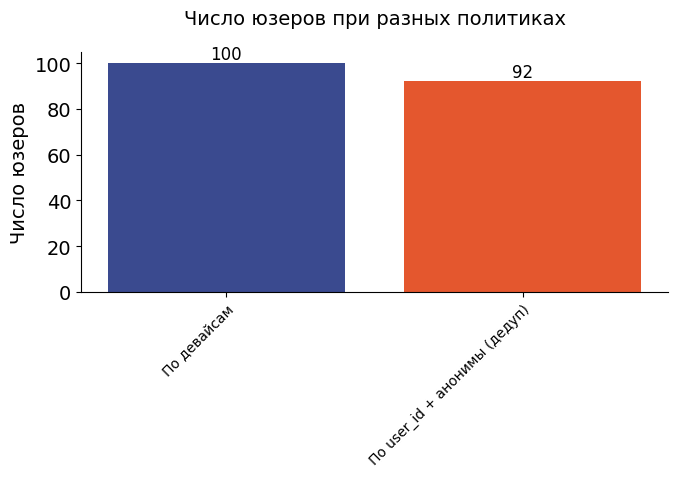

In [10]:
ways_dict = {
    'По девайсам': n_devices,
    'По user_id + анонимы (дедуп)': logged + (n_devices - logged - shared)}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ways_dict.keys(), ways_dict.values(), color=['#3A4A8F', '#E4572E'])
ax.set_title('Число юзеров при разных политиках', pad=20, fontsize=14)
ax.set_ylabel('Число юзеров')
ax.bar_label(bars, fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=10)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

### Сессионизация

Перед расчетом любых количественных метрик стоит начать с вопроса о единице измерения. Один лог агрегируется на трёх уровнях: **события → сессии → пользователи**. И каждая из этих агрегаций отвечает на разные вопросы.


#### Сессия — конструкция, а не факт

В логах нам приходят события с таймстемпами — сессий в данных нет. Мы назначаем их собственными правилами: пауза больше N минут разрезает поток на два визита.

- GA: 30 минут неактивности. Почему 30? Никакого обоснования — исторический дефолт.
- Amplitude: настраивается; мобильные приложения часто берут 5 минут фона.

#### Паттерн вычисления

1) Сортируем по `(user_id, ts)`
2) `shift()` внутри пользователя → пауза с предыдущего события
3) Флаг новой сессии: пауза > порога **или** первое событие пользователя
4) `cumsum()` флагов → номер сессии

#### 🔎 Пример: как связать события в сессию

In [11]:
def sessionize(df, threshold_min=30):

    d = df.sort_values(['user_id', 'ts']).copy()
    gap = d.groupby('user_id')['ts'].diff().dt.total_seconds()
    new_session = gap.isna() | (gap > threshold_min * 60)
    d['session_id'] = d['user_id'] + '_s' + new_session.cumsum().astype(str)
    
    return d

demo = sessionize(events, 30)
demo[['user_id', 'ts', 'event_type', 'session_id']].head(8)

,user_id,ts,event_type,session_id
0,u_00000,2026-08-09 19:33:51.265817312,view,u_00000_s1
1,u_00000,2026-08-09 19:34:01.258479628,view,u_00000_s1
2,u_00000,2026-08-09 19:34:33.363994283,cart,u_00000_s1
3,u_00000,2026-08-11 07:58:42.449213131,view,u_00000_s2
4,u_00000,2026-08-11 07:58:52.251511165,view,u_00000_s2
5,u_00000,2026-08-11 22:28:34.679860394,view,u_00000_s3
6,u_00000,2026-08-11 23:05:50.307705195,view,u_00000_s4
7,u_00000,2026-08-11 23:08:58.729544765,view,u_00000_s4


In [12]:
print(f'При пороге в 30 мин: {demo.session_id.nunique():} сессий, '
      f'уникальных юзеров — {demo.user_id.nunique():}')

При пороге в 30 мин: 92840 сессий, уникальных юзеров — 12000


### Где события теряются и врут?

#### Client-side vs server-side

| | Клиентский трекинг | Серверный трекинг |
|---|---|---|
| Видит | всё поведение: просмотры, клики | только бизнес-события |
| Теряет | **10–30%**: ад-блокеры, потеря интернета | почти ничего (заказ либо в базе, либо нет) |
| Правило | поведенческие события | **критичные для денег события** |

Ключевое — потери систематические, не случайные: ад-блокеры чаще у технической аудитории → теряется конкретный сегмент → искажены сравнения.

#### Дубли

Плохая сеть → клиент ретраит отправку → событие приехало дважды. Поэтому в пайплайне обязательно должна присутствовать дедупликация по `event_id`.


Расхождение в данных разных трекинговых систем — **свойство измерения**. Стоит знать направление и причину смещения, а не пытаться починить разницу до 0.

## Практика

### Данные для семинара

Работаем на синтетическом event-логе e-commerce продукта: ~300 тыс. событий за 5 недель.

Колонки:
- event_id — уникальный идентификатор события
- event_type — тип события (view, cart, purchase)  
- ts — timestamp события
- user_id — идентификатор пользователя  
- platform — платформа (android, ios, web)
- category — категория товара
- product_id — идентификатор товара
- price — цена

В данные намеренно зашит один артефакт, который мы разберем в финальном кейсе.

In [29]:
events.nunique()

event_id      292869
event_type         3
ts            315807
user_id        12000
platform           3
category           6
product_id      3000
price          31010
dtype: int64

In [30]:
events.isna().sum()

event_id      0
event_type    0
ts            0
user_id       0
platform      0
category      0
product_id    0
price         0
dtype: int64

In [31]:
events.ts.max().date() - events.ts.min().date() 

datetime.timedelta(days=35)

#### 1. Сессионизация

Примените `sessionize` с порогом 30 минут. Посчитайте среднее число сессий на пользователя за 5 недель.

In [32]:
s30 = sessionize(events, 30)
per_user = s30.groupby('user_id')['session_id'].nunique()

print(f'Сессий: {s30.session_id.nunique():}; на пользователя: {per_user.mean():.1f} (медиана {per_user.median():.0f})')

Сессий: 92840; на пользователя: 7.7 (медиана 8)


#### 2. Чувствительность к временному порогу

Пересчитайте число сессий при порогах **10 / 30 / 60 минут**.

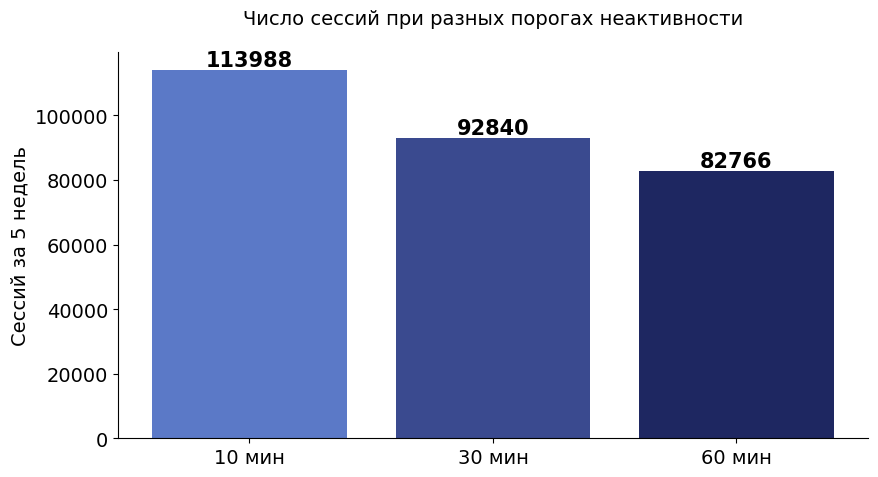

In [17]:
thresholds = [10, 30, 60]
counts = {t: sessionize(events, t).session_id.nunique() for t in thresholds}

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([f'{t} мин' for t in thresholds], counts.values(), color=['#5B79C7', '#3A4A8F', '#1E2761'])
ax.bar_label(bars, fmt='{:.0f}', fontsize=15, fontweight='bold')
ax.set_title('Число сессий при разных порогах неактивности', pad=20, fontsize=14)
ax.set_ylabel('Сессий за 5 недель')
plt.tight_layout(); plt.show()

In [18]:
base = counts[30]
print(f'Относительно порога 30 мин:  10 мин -> {counts[10]/base-1:+.1%},  60 мин -> {counts[60]/base-1:+.1%}')

Относительно порога 30 мин:  10 мин -> +22.8%,  60 мин -> -10.9%


##### Обратите внимание: разные конвенции сессий влияют на bounce rate

Доля сессий-отскоков (ровно 1 событие) при порогах 10/30/60:

In [19]:
bounce_rate = {t: (sessionize(events, t).groupby('session_id').size() == 1).mean() for t in [10, 30, 60]}

for t, v in bounce_rate.items():
    print(f'{t} мин: {v:.1%}')

10 мин: 26.2%
30 мин: 14.5%
60 мин: 8.0%


#### 3. Воронка и единица расчета

Посчитайте конверсию **view → cart → purchase** тремя способами: по **событиям**, по **сессиям**, по **пользователям** (на `s30`).

In [33]:
def funnel(df, unit):
    
    if unit == 'events':
        c = df.event_type.value_counts()
        
        return {'view2cart': c['cart'] / c['view'], 'cart2purchase': c['purchase'] / c['cart']}
    
    key = 'session_id' if unit == 'sessions' else 'user_id'
    
    has = df.groupby(key)['event_type'].agg(set)
    
    v = has.apply(lambda s: 'view' in s).sum()
    ca = has.apply(lambda s: 'cart' in s).sum()
    p = has.apply(lambda s: 'purchase' in s).sum()
    
    return {'view2cart': ca / v, 'cart2purchase': p / ca}

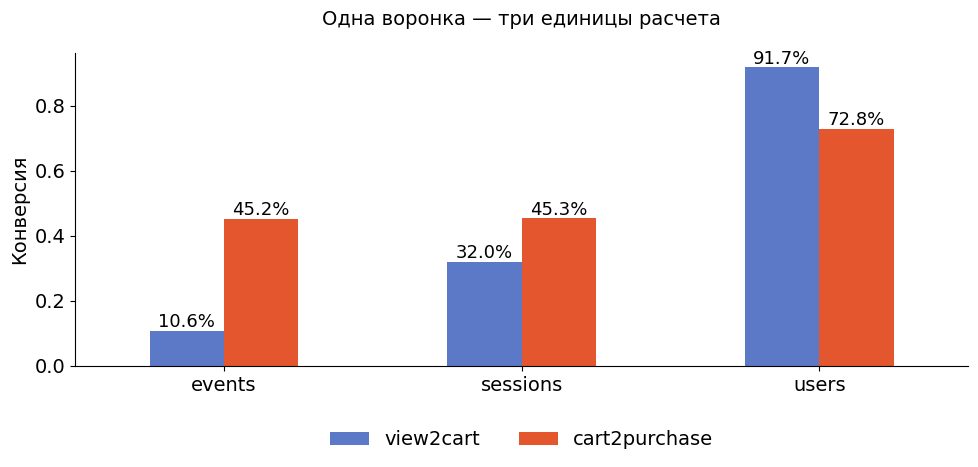

In [34]:
res = pd.DataFrame({u: funnel(s30, u) for u in ['events', 'sessions', 'users']}).T

fig, ax = plt.subplots(figsize=(10, 5))
res.plot.bar(ax=ax, color=['#5B79C7', '#E4572E'], rot=0)
ax.set_title('Одна воронка — три единицы расчета', pad=20, fontsize=14)
ax.set_ylabel('Конверсия'); ax.set_xlabel('')

for cont in ax.containers: ax.bar_label(cont, fmt='{:.1%}', fontsize=13)
legend_below(ax, ncol=2)
plt.tight_layout(); plt.show()

#### 4. События в разрезе платформ

Посчитайте среднее число событий на сессию в разрезе платформ.

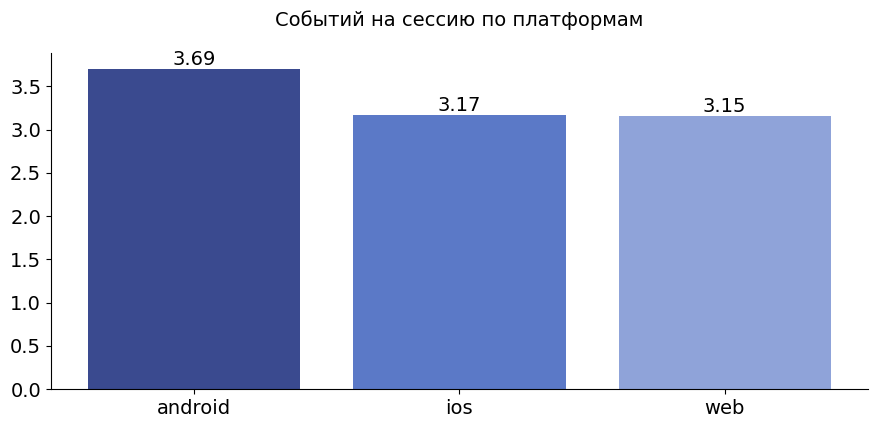

In [35]:
event_per_session = s30.groupby(['platform', 'session_id']).size().groupby('platform').mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(event_per_session.index, event_per_session.values, color=['#3A4A8F', '#5B79C7', '#8FA3D9'])
ax.bar_label(bars, fmt='{:.2f}', fontsize=14)
ax.set_title('Событий на сессию по платформам', pad=20, fontsize=14)
plt.tight_layout(); plt.show()

**Что выглядит аномально?**

### Финальный кейс: «Конверсия упала — продукт или трекинг?»

После релиза 24/08 конверсия view2purchase просела процентов на 10–15 и не восстанавливается. Что мы сломали в продукте?

**Ваша задача** — полное расследование в стиле ДЗ 1, но с сегодняшними инструментами:

1. Подтвердите падение: динамика конверсии view2purchase **по дням** (по событиям).
2. Проверьте единицу счёта: та же динамика **по пользователям**. Совпадает ли картина?
3. Локализуйте срезами (семинар 1): платформа?
4. Найдите механизм: что именно изменилось в данных после релиза?
5. Почините и проверьте: пересчитайте конверсию после фикса.
6. Напишите ответ PM в 3–4 предложениях: что случилось, продукт или трекинг, что делать.

**Подсказки**:
- Семинар 1: если ratio-метрика упала — смотрите числитель и знаменатель отдельно.
- Блок 4 сегодня: какое свойство события позволяет опознать дубль?

#### Шаг 1-2. Динамика конверсии по дням: события vs пользователи

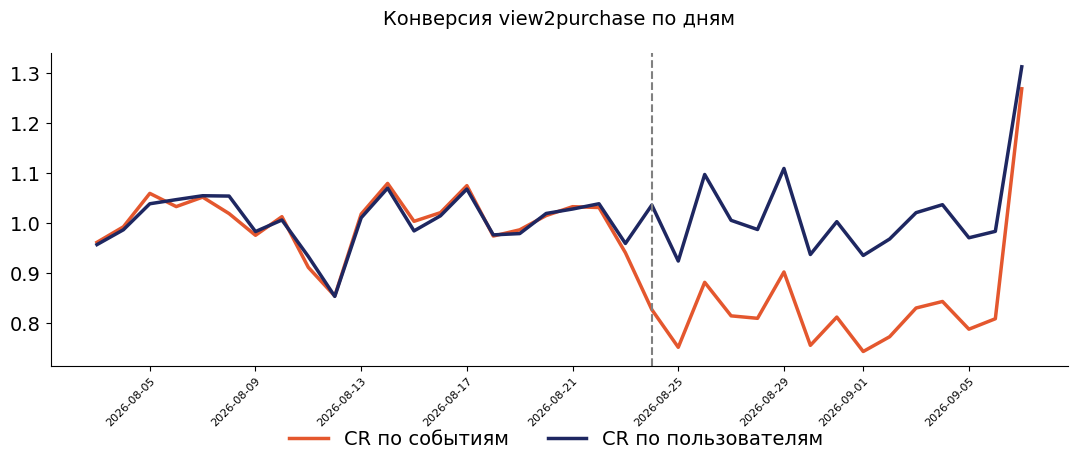

In [36]:
ev = events.assign(date=events.ts.dt.date)
daily_e = ev.pivot_table(index='date', columns='event_type', values='event_id', aggfunc='count')
cr_events = daily_e['purchase'] / daily_e['view']

by_user = ev.groupby(['date', 'user_id'])['event_type'].agg(set).reset_index()
daily_u = by_user.groupby('date')['event_type'].agg(
    viewers=lambda s: s.apply(lambda x: 'view' in x).sum(),
    buyers=lambda s: s.apply(lambda x: 'purchase' in x).sum())
cr_users = daily_u.buyers / daily_u.viewers

fig, ax = plt.subplots()
ax.plot(cr_events.index, cr_events / cr_events.iloc[:14].mean(), lw=2.5,
        label='CR по событиям', color='#E4572E')
ax.plot(cr_users.index, cr_users / cr_users.iloc[:14].mean(), lw=2.5,
        label='CR по пользователям ', color='#1E2761')

ax.axvline(pd.Timestamp('2026-08-24'), ls='--', color='grey')

ax.set_title('Конверсия view2purchase по дням', pad=20, fontsize=14)

legend_below(ax, ncol=2)
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.tight_layout(); 
plt.show()

#### Шаг 3. Локализация срезом: views на пользователя по платформам

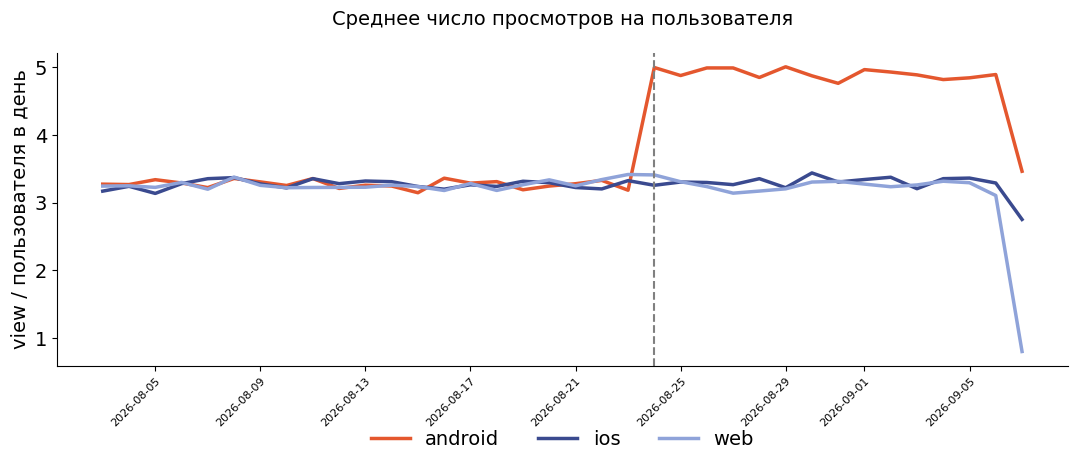

In [37]:
vpu = ev[ev.event_type == 'view'].groupby(['date', 'platform']).size().unstack()
upu = ev.groupby(['date', 'platform'])['user_id'].nunique().unstack()
ratio = vpu / upu

fig, ax = plt.subplots()
for p, c in zip(['android', 'ios', 'web'], ['#E4572E', '#3A4A8F', '#8FA3D9']):
    ax.plot(ratio.index, ratio[p], lw=2.5, label=p, color=c)
ax.axvline(pd.Timestamp('2026-08-24'), ls='--', color='grey')
ax.set_title('Среднее число просмотров на пользователя', pad=20, fontsize=14)
ax.set_ylabel('view / пользователя в день')

legend_below(ax)
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.tight_layout(); 
plt.show()

#### Шаг 4. Механизм: что за лишние view? Проверяем дубли по event_id

In [38]:
dup_share = ev[ev.event_type == 'view'].groupby(['date', 'platform'])['event_id'] \
              .agg(lambda s: s.duplicated().mean()).unstack()

print('Доля дублей view по event_id):\n')
print(dup_share.tail(20).round(3).to_string())

Доля дублей view по event_id):

platform    android  ios  web
date                         
2026-08-19    0.000  0.0  0.0
2026-08-20    0.000  0.0  0.0
2026-08-21    0.000  0.0  0.0
2026-08-22    0.000  0.0  0.0
2026-08-23    0.000  0.0  0.0
2026-08-24    0.337  0.0  0.0
2026-08-25    0.333  0.0  0.0
2026-08-26    0.340  0.0  0.0
2026-08-27    0.336  0.0  0.0
2026-08-28    0.337  0.0  0.0
2026-08-29    0.333  0.0  0.0
2026-08-30    0.329  0.0  0.0
2026-08-31    0.340  0.0  0.0
2026-09-01    0.336  0.0  0.0
2026-09-02    0.332  0.0  0.0
2026-09-03    0.335  0.0  0.0
2026-09-04    0.328  0.0  0.0
2026-09-05    0.330  0.0  0.0
2026-09-06    0.335  0.0  0.0
2026-09-07    0.378  0.0  0.0


#### Шаг 5. Фикс: дедупликация — и проверка

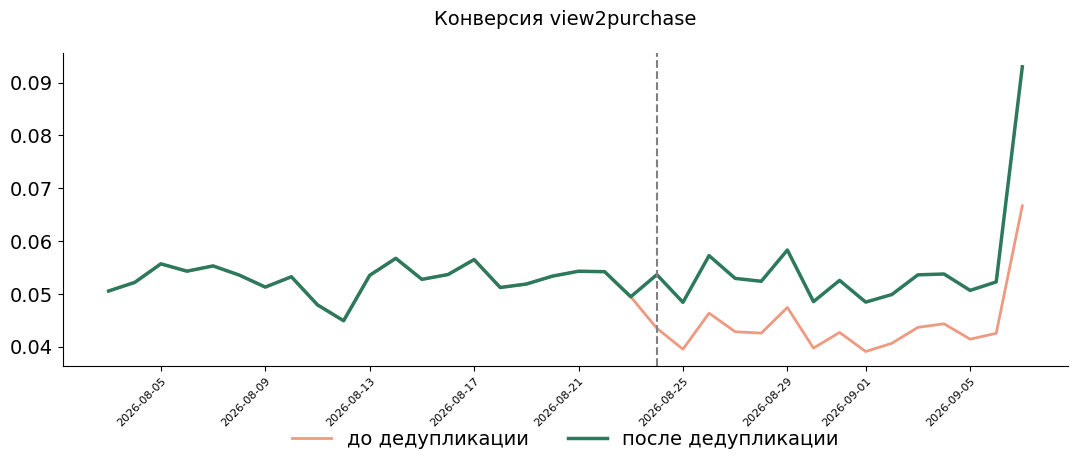

In [39]:
clean = events.drop_duplicates('event_id')
ce = clean.assign(date=clean.ts.dt.date)
d = ce.pivot_table(index='date', columns='event_type', values='user_id', aggfunc='count')
cr_fixed = d['purchase'] / d['view']

fig, ax = plt.subplots()
ax.plot(cr_events.index, cr_events, lw=2, label='до дедупликации', color='#E4572E', alpha=0.6)
ax.plot(cr_fixed.index, cr_fixed, lw=2.5, label='после дедупликации', color='#2C7A5B')
ax.axvline(pd.Timestamp('2026-08-24'), ls='--', color='grey')
ax.set_title('Конверсия view2purchase', pad=20, fontsize=14)

legend_below(ax, ncol=2)
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.tight_layout(); 
plt.show()

In [40]:
events[(events['event_type'] == 'view') & (events['platform'] == 'android')].event_id.count() \
    / events[(events['event_type'] == 'view') & (events['platform'] == 'android')].event_id.nunique() - 1

0.20202215920100053

In [41]:
events[(events['event_type'] == 'view') & (events['platform'] == 'android')].drop_duplicates('event_id').event_id.count() \
    / events[(events['event_type'] == 'view') & (events['platform'] == 'android')].event_id.nunique() - 1

0.0

#### Шаг 6. Сообщение для команды

- Продукт не сломан: доля покупающих пользователей после релиза не изменилась.
- Падение CR — артефакт трекинга: Android-клиент с релиза 24/08 дублирует отправку событий view (ретраи с одинаковым event_id), знаменатель конверсии раздулся на ~20% только на Android.
- Данные чинятся дедупликацией по event_id; клиенту нужен фикс ретраев. Дашборды до фикса читать по дедуплицированной витрине.

### Чеклист: правила работы с событиями

**1. Проектирование**
- **1.1)** Трекинг проектируется **от метрики**, не от интерфейса. Событие без метрики-потребителя — кандидат на невключение.
- **1.2)** **Одно действие — одно событие**; вариации — в атрибуты (`order_completed` + `source: cart|wishlist|one_click`, а не три события).
- **1.3)** Логируйте **результат**, не только намерение: шаг воронки — показ экрана, клик — диагностика; их разрыв — метрика технических потерь.
- **1.4)** Событие — то, что **произошло**; состояние — свойство (`subscription_upgraded`, а не `user_is_premium`).
- **1.5)** Выводимое не трекается: сессии и агрегаты вычисляются из событий, а не пишутся клиентом.

**2. Структура**
- **2.1)** Каркас свойств интерактивных событий: `element_name` (единый словарь с UX-разметкой), `screen_from`, `screen_to` (ожидаемая цель — для клика), `source_element` + обязательный `source_type: button|deeplink|push|back|direct` (фактический источник — для показа экрана).
- **2.2)** Исторически точное — в **свойства события**; текущее — в свойства пользователя.
- **2.3)** Единая naming-конвенция (Object-Action, `order_completed`) — любая, но одна.
- **2.4)** Свойства типизированы и перечислимы.
- **2.5)** Персональные данные не пишутся в атрибуты.

**3. Идентичность**
- **3.1)** Пишем в событие все доступные пользовательские идентификаторы (`cookie` и `device_id` всегда, `user_id` как только есть).
- **3.2)** Политика склейки «аноним → логин» выбрана явно и задокументирована.
- **3.3)** Фильтры «не-людей» (боты, тесты, сотрудники, мультиаккаунты) известны и документированы; помните, что они концентрируются в срезах.

**4. Надёжность**
- **4.1)** Деньги — сервер, поведение — клиент.
- **4.2)** `event_id` + дедупликация: ретраи — норма, идемпотентность — обязанность пайплайна.
- **4.3)** Два таймстемпа (клиент/сервер); часовой пояс агрегации зафиксирован.

**5. Процесс**
- **5.1)** Трекинг-план — живой документ с владельцем; разметка не уходит в разработку без фиксирования описанных выше правил.
- **5.2)** *Что и зачем* — аналитик; *как* — инженер.
- **5.3)** Перед тем, как заводить новое событие, ответьте себе на вопросы:
    - (1) для какой метрики оно необходимо?
    - (2) не атрибут ли это уже существующего события?
    - (3) нас интересует результат или намерение?
    - (4) какой полный необходимый список свойств и идентификаторов?
    - (5) кто будет владельцем события?